In [1]:
import numpy as np
from matplotlib import pyplot as plt
import random
import os
import pandas as pd

from scipy.spatial import ConvexHull, convex_hull_plot_2d
from sklearn.preprocessing import MinMaxScaler

from scipy.optimize import minimize

import math

from math import sqrt, exp
import cv2

### Post-run analysis
> find final pareto points
>  

130 130 130 130


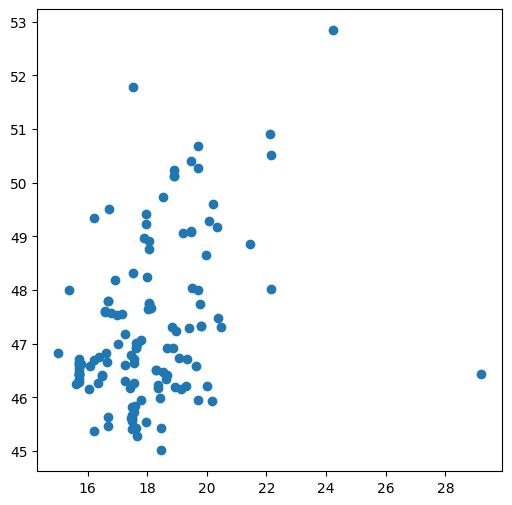

In [2]:
# Get data from file (For notebook purpose)
with open('data_file') as f:
    lines = f.readlines()
lines = lines[2:]
inds = [line.split()[0] for line in lines]
ens = [float(line.split()[-4]) for line in lines]
obj0s = [float(line.split()[-3]) for line in lines]
obj1s = [float(line.split()[-2]) for line in lines]
print (len(lines), len(ens), len(obj0s), len(obj1s))

plt.figure(figsize=(6, 6))
plt.scatter(obj0s, obj1s)
plt.show()

In [3]:
# Remove the solution
rem_inds = []
en_low_cutoff = -10
en_high_cutoff = 30
mismatch_low_cutoff = -1
mismatch_high_cutoff = 111
for i in range(len(obj0s)):
    if en_high_cutoff < obj0s[i] or obj0s[i] < en_low_cutoff :
        rem_inds.append(i)
    elif mismatch_high_cutoff < obj1s[i] or obj1s[i] < mismatch_low_cutoff:
        rem_inds.append(i)
print ('removing following indices from data: ', rem_inds)

rem_inds.sort(reverse=True)

xtra_inds, xtra_labels, xtra_obj0s, xtra_obj1s = [], [], [], []
for i in rem_inds:
    xtra_inds.append(i)
    xtra_labels.append(inds.pop(i))
    xtra_obj0s.append(obj0s.pop(i))
    xtra_obj1s.append(obj1s.pop(i))
    
print (xtra_inds, xtra_labels, xtra_obj0s, xtra_obj1s)

removing following indices from data:  []
[] [] [] []


In [4]:
w0, w1, w2, w3, w4 = 1, 1, 1, 1, 1
weights = np.array([[w0], [w1], [w2], [w3], [w4]]).T

v0, v1 = obj0s, obj1s
v2 = np.zeros(len(v0)); v3, v4 = v2, v2

vals = np.array([v0, v1, v2, v3, v4]).T

In [5]:
# Fairly fast for many datapoints, less fast for many costs, somewhat readable
def is_pareto_efficient_simple(costs):
    """
    Source: https://github.com/QUVA-Lab/artemis/blob/peter/artemis/general/pareto_efficiency.py

    Find the pareto-efficient points

    param costs: An (n_points, n_costs) array

    returns: A (n_points, ) boolean array, indicating whether each point is
             Pareto efficient
    """
    is_efficient = np.ones(costs.shape[0], dtype = bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient]<c, axis=1)  # Keep any point with a lower cost
            is_efficient[i] = True  # And keep self
    return is_efficient

def point_on_two_lines(line1, line2):
    """
    Returns the point of intersection of two lines

    Args:

    line1: list/tuple (m1, c1) for line y = m1x + c1
    line2: list/tuple (m2, c2) for line y = m2x + c2
    """
    m1, c1 = line1
    m2, c2 = line2

    # y coordinate in point of intersection of two lines
    y_c = (m1 * c2 - m2 * c1) / (m1 - m2)
    # substitute y_c in y = m1x + c to get x_c
    x_c = (y_c - c1) / m1

    return x_c, y_c


def line_from_points(p1, p2):
    """
    Get equation of line given two points

    Args:

    p1: tuple/list of point 1
    p2: tuple/list of point 2
    """
    # slope
    m = (p2[1] - p1[1]) / (p2[0] - p1[0])
    c = p1[1] - m * p1[0]

    return m, c

def dist_from_point(P, xy):
    """
    Returns distance between two points

    Args:

    P: point one
    xy: point two
    """
    return math.sqrt((P[0] - xy[0]) ** 2 + (P[1] - xy[1]) ** 2)

def optimize_exponential_constant(k, scaled_good_pool_values):
    """
    A scalar function to minimize the exponential constant to give required
    number of models with probability above 0.5 (or 50%).

    Args:

    k: (a list or an array) of the variable for minimize function (Eg: [-1])

    scaled_good_pool_values: (1D array or list) The objective function
                             values of models in good pool scaled between 0
                             and 1. For example, distances_from_hull for
                             multiobjective optimization
    """
    num_required_above_50 = 100
    # Get probs based on constant k
    exponential_probs = [math.exp(k[0]*i) for i in scaled_good_pool_values]
    num_above_50 = len([i for i in exponential_probs if i > 0.5])

    return (num_required_above_50 - num_above_50)**2

def norm_opt(k, num_required_above_50, scaled_good_pool_values):
    
    # Get probs based on constant k
    exponential_probs = [(exp(k[0]*i) - exp(k[0])) / (1- exp(k[0])) \
                                        for i in scaled_good_pool_values]
    num_above_50 = len([i for i in exponential_probs if i > 0.5])

    return (num_required_above_50 - num_above_50)**2


In [6]:
# normalize using MinMaxScaler
scaler = MinMaxScaler()
norm_vals = scaler.fit_transform(vals)
weighted_norm_vals = norm_vals/weights

# For now only 2D
weighted_norm_vals = weighted_norm_vals[:, :2]

# weighted norm vals is are for each model -
# [[obj0, obj1, ..], [obj0, obj1, ..], ... ,[obj0, obj1, ..]]

# Get indices of points (models) which are pareto efficient
pareto_true_inds= is_pareto_efficient_simple(weighted_norm_vals)
pareto_true_inds.tolist()
pareto_points_inds = [i for i, b in enumerate(pareto_true_inds) \
                                            if b==True]
pareto_points = [list(weighted_norm_vals[i]) for i in pareto_points_inds]

# Add origin in the beginning to find convex hull visible from origin
pareto_points = [[0 for i in range(len(pareto_points[0]))]] + \
                                            pareto_points

pareto_points.sort()
pareto_points = np.array(pareto_points)

# Make convex hull with pareto points
hull = ConvexHull(pareto_points, qhull_options='QG0')
# Get visible facets from (0, 0)
visible_facets = []
hull_points = []
for facet in hull.simplices[hull.good]:
    vis_facets = hull.points[facet]
    visible_facets.append(vis_facets)
    if tuple(vis_facets[0]) not in hull_points:
        hull_points.append(tuple(vis_facets[0]))
    if tuple(vis_facets[1]) not in hull_points:
        hull_points.append(tuple(vis_facets[1]))

hull_points = np.array([list(i) for i in hull_points])

# Assuming 2D pareto front from here
# Get maximum x & maximum y hull points
Px = hull_points[hull_points[:, 0].argmax()]
Py = hull_points[hull_points[:, 1].argmax()]

# slope of line between Px, Py
m_pxpy = (Px[1] - Py[1]) / (Px[0] - Py[0])

distances_from_hull = []
for data_of_model in weighted_norm_vals:
    # get equation of line perpendicular to PxPy & passes through model
    c_xy = data_of_model[1] - (-1/m_pxpy) * data_of_model[0]
    xy_line = (-1/m_pxpy, c_xy)

    # find distance of the model from each visible facet along this line
    distances = []
    for facet in visible_facets:
        # get equation (m, c) for a facet
        facet_line = line_from_points(facet[0], facet[1])
        # Get point of intersection with facet_line
        x0y0 = point_on_two_lines(facet_line, xy_line)
        distances.append(dist_from_point(x0y0, data_of_model))
    distances_from_hull.append(min(distances))

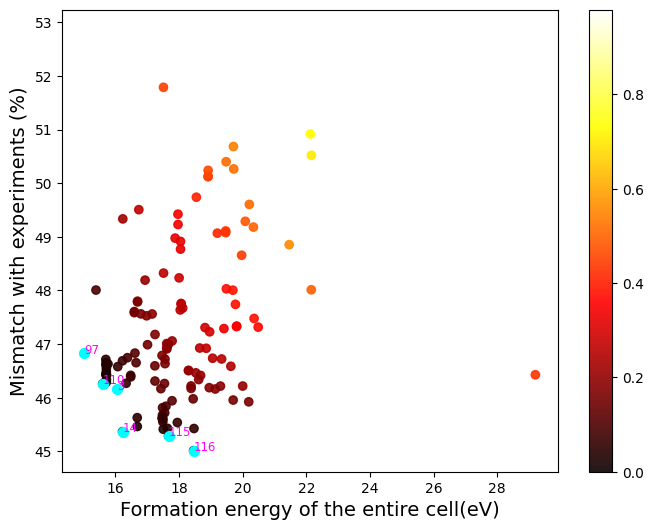

In [7]:
plt.figure(figsize=(8, 6))

pareto_xs = [obj0s[i] for i in pareto_points_inds]
pareto_ys = [obj1s[i] for i in pareto_points_inds]

plt.scatter(obj0s, 
            obj1s, 
            c=distances_from_hull, cmap='hot', alpha=0.9)
plt.colorbar()
plt.scatter(pareto_xs, pareto_ys, c='cyan', s=50)#, marker='d')
labels = [inds[i] for i in pareto_points_inds]
for i, txt in enumerate(labels):
    plt.annotate(txt, (pareto_xs[i], pareto_ys[i]), c='magenta', size='small')
plt.xlabel('Formation energy of the entire cell(eV)', fontsize=14)
plt.ylabel('Mismatch with experiments (%)', fontsize=14)
plt.show()

In [8]:
print (labels)
pp = ""
for i in labels:
    pp += i
    pp += " "
print (pp)

['3', '14', '97', '110', '115', '116']
3 14 97 110 115 116 


In [9]:
9 32 35 50 59 64 88 98

SyntaxError: invalid syntax (261017501.py, line 1)

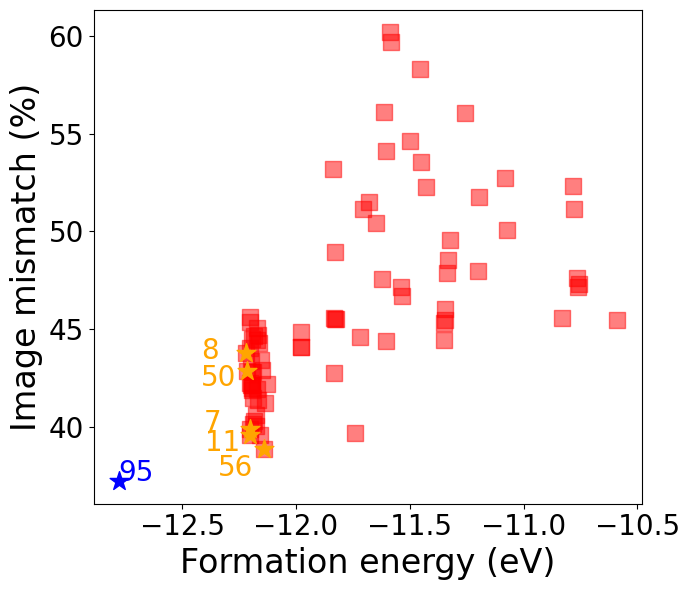

In [82]:
#plt.close()
plt.figure(figsize=(7, 6))

pareto_xs = np.array([obj0s[i] for i in pareto_points_inds])
pareto_ys = np.array([obj1s[i] for i in pareto_points_inds])

plt.scatter(obj0s, obj1s, c='red', marker='s', s=120, alpha=0.5)


# magenta star & label the pareto front 
pareto_labels = labels

# blue star the solutions (if exists)
x_adjust = [-0.2 for i in range(len(labels))]
y_adjust = np.array([-0.1, -0.3, -0.8, -0.8, -1.4]) * 1

for i, label in enumerate(pareto_labels):
    plt.scatter(pareto_xs[i], pareto_ys[i], c='orange', marker='*', s=200)
    plt.annotate(label, (pareto_xs[i]+x_adjust[i], pareto_ys[i]+y_adjust[i]), c='orange', size=20)

for i in range(len(xtra_labels)):
    plt.scatter(xtra_obj0s[i], xtra_obj1s[i], c='blue', marker='*', s=200)
    plt.annotate(xtra_labels[i], (xtra_obj0s[i], xtra_obj1s[i]), c='blue', size=20)
    
# highlight pareto points
#plt.scatter(pareto_xs, pareto_ys, c='white', s=200, marker='s')
#plt.scatter(pareto_xs, pareto_ys, c='blue', s=120, marker='*')
#plt.scatter(pareto_xs, pareto_ys, c='blue', s=120, marker='*')
#labels = [inds[i] for i in pareto_points_inds]
#for i, txt in enumerate(labels):
#    plt.annotate(txt, (pareto_xs[i], pareto_ys[i]), c='magenta', size='medium')

plt.xlabel('Formation energy (eV)', fontsize=24)
plt.ylabel('Image mismatch (%)', fontsize=24)
plt.xticks(ticks=[-12.5, -12.0, -11.5, -11.0, -10.5], fontsize=20)
plt.yticks(ticks=[40, 45, 50, 55, 60], fontsize=20)
plt.tight_layout()
plt.savefig('CdTe_run3_pareto.png')
plt.show()
plt.close()